In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
data = pd.read_excel("Amazon.xlsx")
data

,Unnamed: 0,Velocidad Entrega,Precio,Durabilidad,Imagen Producto,Valor Educativo,Servicio Retorno,Tamano Paquete,Calidad Producto,Numero Estrellas
0,Adam,205,3,345,235,24,23,26,21,17
1,Anna,9,15,315,33,25,4,42,215,28
2,Bernard,17,26,285,3,43,27,41,26,33
3,Edward,135,5,355,295,18,23,39,195,17
4,Emilia,3,45,48,39,34,46,225,34,43
...,...,...,...,...,...,...,...,...,...,...
95,Teofan,3,8,32,25,7,21,42,17,1
96,Teofil,305,25,46,24,33,28,355,26,45
97,Teofila,1,14,26,25,24,27,42,185,23
98,Teon,155,11,335,34,26,29,42,215,27


In [3]:
nombres = data.iloc[:, 0]
datos = data.iloc[:, 1:]

datos.head()

,Velocidad Entrega,Precio,Durabilidad,Imagen Producto,Valor Educativo,Servicio Retorno,Tamano Paquete,Calidad Producto,Numero Estrellas
0,205,3,345,235,24,23,26,21,17
1,9,15,315,33,25,4,42,215,28
2,17,26,285,3,43,27,41,26,33
3,135,5,355,295,18,23,39,195,17
4,3,45,48,39,34,46,225,34,43


In [4]:
from sklearn.preprocessing import normalize

data_scaled = normalize(datos)
data_scaled

array([[0.43826336, 0.00641361, 0.73756517, 0.50239946, 0.05130888,
        0.04917101, 0.05558462, 0.04489527, 0.03634379],
       [0.02323527, 0.03872544, 0.81323434, 0.08519598, 0.06454241,
        0.01032679, 0.10843125, 0.55506471, 0.0722875 ],
       [0.05723452, 0.08753514, 0.95951982, 0.01010021, 0.14476966,
        0.09090188, 0.13803618, 0.08753514, 0.11110229],
       [0.25885639, 0.00958727, 0.68069644, 0.56564916, 0.03451419,
        0.04410146, 0.07478074, 0.37390368, 0.03259673],
       [0.01197502, 0.17962533, 0.19160036, 0.15567529, 0.13571692,
        0.18361701, 0.89812667, 0.13571692, 0.17164198],
       [0.14494006, 0.251738  , 0.60264551, 0.03661644, 0.03966781,
        0.02898801, 0.73995715, 0.03356507, 0.00457705],
       [0.04755854, 0.02481315, 0.98218723, 0.06823617, 0.07237169,
        0.09304932, 0.07857498, 0.05996511, 0.06410064],
       [0.13323393, 0.04304481, 0.06354234, 0.52268696, 0.05739308,
        0.04509456, 0.70716471, 0.44069685, 0.05944283],


In [5]:
data_scaled = pd.DataFrame(data_scaled, columns = datos.columns)
data_scaled.head()

,Velocidad Entrega,Precio,Durabilidad,Imagen Producto,Valor Educativo,Servicio Retorno,Tamano Paquete,Calidad Producto,Numero Estrellas
0,0.438263,0.006414,0.737565,0.502399,0.051309,0.049171,0.055585,0.044895,0.036344
1,0.023235,0.038725,0.813234,0.085196,0.064542,0.010327,0.108431,0.555065,0.072287
2,0.057235,0.087535,0.959520,0.010100,0.144770,0.090902,0.138036,0.087535,0.111102
3,0.258856,0.009587,0.680696,0.565649,0.034514,0.044101,0.074781,0.373904,0.032597
4,0.011975,0.179625,0.191600,0.155675,0.135717,0.183617,0.898127,0.135717,0.171642


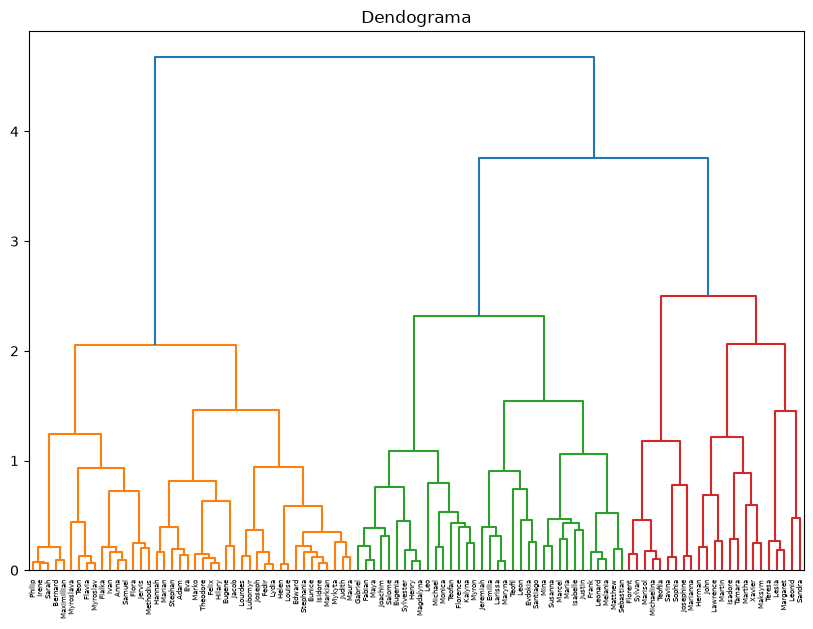

In [6]:
import scipy.cluster.hierarchy as shc

plt.figure(figsize=(10,7))
plt.title("Dendograma")

dend = shc.dendrogram(
    shc.linkage(data_scaled, method='ward'),
    labels=nombres.to_list()
)

plt.show()

In [7]:
colores_unicos = set(dend['color_list'])
num_clusters_optimo = len(colores_unicos) - 1
num_clusters_optimo

3

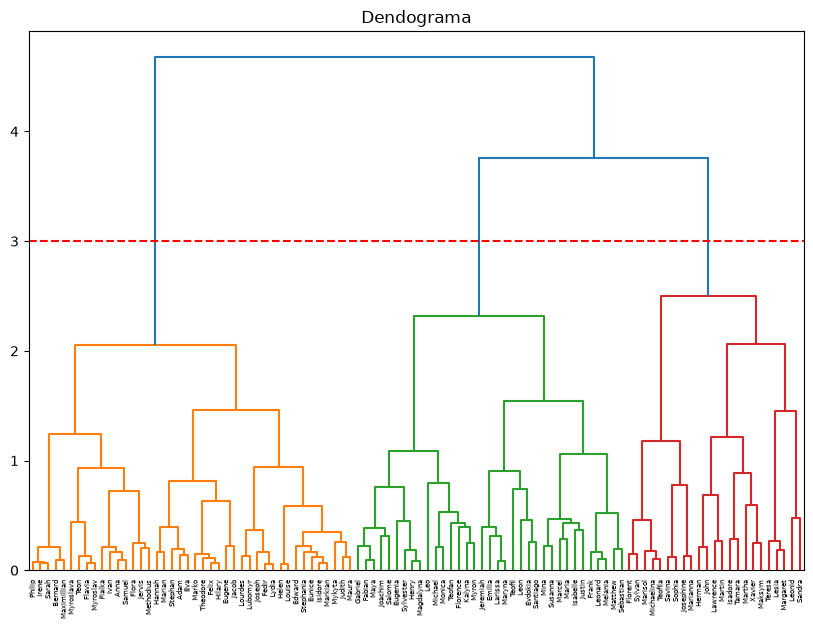

In [8]:
plt.figure(figsize=(10,7))
plt.title("Dendograma")

dend = shc.dendrogram(
    shc.linkage(data_scaled, method='ward'),
    labels=nombres.to_list()
)

plt.axhline(y=3, color='r', linestyle='--')
plt.show()

In [9]:
from sklearn.cluster import AgglomerativeClustering

cluster = AgglomerativeClustering(
    n_clusters=3,
    metric='euclidean',
    linkage='ward'
)

grupos = cluster.fit_predict(data_scaled)
grupos

array([1, 1, 1, 1, 2, 2, 1, 2, 0, 2, 0, 2, 1, 2, 1, 1, 1, 2, 1, 1, 2, 1,
       1, 1, 1, 1, 0, 2, 1, 1, 0, 1, 1, 0, 1, 1, 2, 1, 2, 0, 2, 0, 1, 2,
       2, 2, 0, 2, 2, 0, 0, 2, 1, 1, 1, 2, 0, 2, 0, 2, 1, 0, 1, 1, 0, 0,
       2, 2, 1, 2, 1, 2, 1, 2, 0, 2, 2, 1, 2, 1, 1, 2, 1, 0, 1, 0, 2, 0,
       1, 1, 2, 0, 2, 0, 1, 2, 2, 0, 1, 0])

In [10]:
dataframe = pd.DataFrame(grupos, columns=['grupo'])
dataframe.head()

,grupo
0,1
1,1
2,1
3,1
4,2


In [11]:
dataframe2 = pd.concat([data, dataframe], axis=1, join='inner')
dataframe2

,Unnamed: 0,Velocidad Entrega,Precio,Durabilidad,Imagen Producto,Valor Educativo,Servicio Retorno,Tamano Paquete,Calidad Producto,Numero Estrellas,grupo
0,Adam,205,3,345,235,24,23,26,21,17,1
1,Anna,9,15,315,33,25,4,42,215,28,1
2,Bernard,17,26,285,3,43,27,41,26,33,1
3,Edward,135,5,355,295,18,23,39,195,17,1
4,Emilia,3,45,48,39,34,46,225,34,43,2
...,...,...,...,...,...,...,...,...,...,...,...
95,Teofan,3,8,32,25,7,21,42,17,1,2
96,Teofil,305,25,46,24,33,28,355,26,45,2
97,Teofila,1,14,26,25,24,27,42,185,23,0
98,Teon,155,11,335,34,26,29,42,215,27,1


In [12]:
# Poner los nombres de los clientes como índice
dataframe2 = dataframe2.rename(columns={'Unnamed: 0': 'Cliente'})
dataframe2 = dataframe2.set_index('Cliente')

dataframe2

,Velocidad Entrega,Precio,Durabilidad,Imagen Producto,Valor Educativo,Servicio Retorno,Tamano Paquete,Calidad Producto,Numero Estrellas,grupo
Cliente,,,,,,,,,,
Adam,205,3,345,235,24,23,26,21,17,1
Anna,9,15,315,33,25,4,42,215,28,1
Bernard,17,26,285,3,43,27,41,26,33,1
Edward,135,5,355,295,18,23,39,195,17,1
Emilia,3,45,48,39,34,46,225,34,43,2
...,...,...,...,...,...,...,...,...,...,...
Teofan,3,8,32,25,7,21,42,17,1,2
Teofil,305,25,46,24,33,28,355,26,45,2
Teofila,1,14,26,25,24,27,42,185,23,0


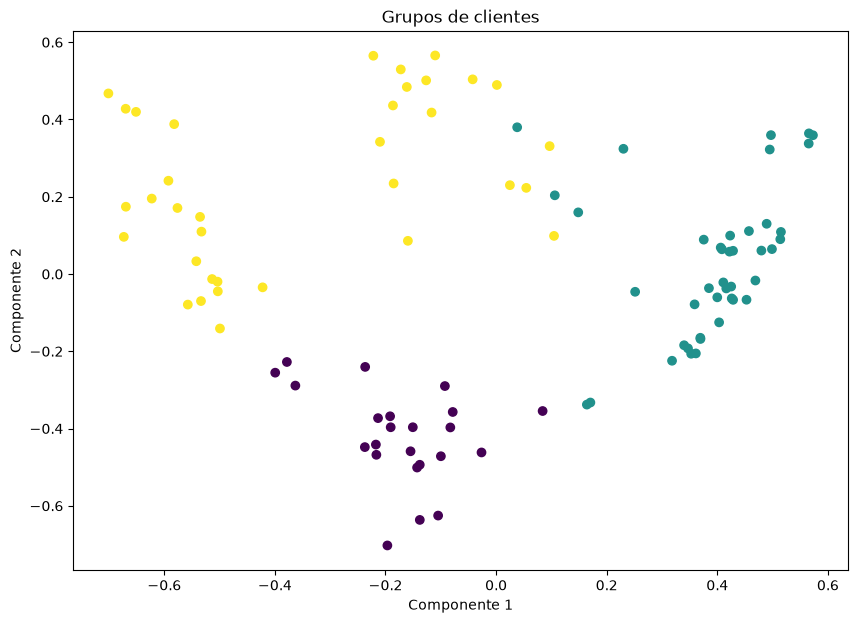

In [13]:
# Análisis gráfico con PCA
from sklearn import decomposition

campos = data_scaled

pca = decomposition.PCA(n_components=2)
pca.fit(campos)

campos = pca.transform(campos)

plt.figure(figsize=(10,7))
plt.scatter(campos[:,0], campos[:,1], c=cluster.labels_)
plt.title("Grupos de clientes")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.show()

In [14]:
# Grupo de Salome, Stephania y Lydia
dataframe2.loc[['Salome', 'Stephania', 'Lydia'], ['grupo']]

,grupo
Cliente,
Salome,2
Stephania,1
Lydia,1


In [15]:
# Clientes que pertenecen a los mismos grupos

print("Clientes del grupo de Salome:")
print(dataframe2[dataframe2['grupo'] == 2].index.tolist())

print("\nClientes del grupo de Stephania y Lydia:")
print(dataframe2[dataframe2['grupo'] == 1].index.tolist())

Clientes del grupo de Salome:
['Emilia', 'Fabian', 'Frank', 'Gabriel', 'Henry', 'Isabelle', 'Eugenia', 'Evdokia', 'Florence', 'Jeremiah', 'Joachim', 'Santiago', 'Justin', 'Kalyna', 'Larissa', 'Leon', 'Leonard', 'Leo', 'Magdalyna', 'Marcel', 'Maria', 'Maryna', 'Matthew', 'Maya', 'Melania', 'Michael', 'Mina', 'Monica', 'Myron', 'Salome', 'Sebastian', 'Susanna', 'Sylvester', 'Teofan', 'Teofil']

Clientes del grupo de Stephania y Lydia:
['Adam', 'Anna', 'Bernard', 'Edward', 'Philip', 'Irene', 'Isidore', 'Joseph', 'Eugene', 'Eunice', 'Eva', 'Fedir', 'Felix', 'Fialka', 'Flavia', 'Flora', 'Hannah', 'Helen', 'Hilary', 'Lourdes', 'Ivan', 'Jacob', 'Jervis', 'Judith', 'Louise', 'Lubomyr', 'Lydia', 'Marian', 'Markian', 'Marko', 'Maura', 'Maximillian', 'Methodius', 'Mykyta', 'Myroslav', 'Myroslava', 'Samuel', 'Sarah', 'Stephan', 'Stephania', 'Theodore', 'Teon']


In [16]:
# Buscar los clientes más parecidos dentro de cada grupo

datos_norm = data_scaled.copy()
datos_norm.index = nombres

for cliente in ['Salome', 'Stephania', 'Lydia']:
    
    grupo_cliente = dataframe2.loc[cliente, 'grupo']
    
    mismos_grupo = dataframe2[dataframe2['grupo'] == grupo_cliente].index
    candidatos = mismos_grupo.drop(cliente)
    
    distancias = ((datos_norm.loc[candidatos] - datos_norm.loc[cliente])**2).sum(axis=1)**0.5
    
    print("\nClientes más parecidos a", cliente)
    print(distancias.sort_values().head(3))


Clientes más parecidos a Salome
Cliente
Magdalyna    0.240485
Fabian       0.260858
Kalyna       0.264026
dtype: float64

Clientes más parecidos a Stephania
Cliente
Isidore    0.113862
Markian    0.122812
Judith     0.135496
dtype: float64

Clientes más parecidos a Lydia
Cliente
Fedir      0.056111
Joseph     0.125220
Lourdes    0.252586
dtype: float64
